1. **Data Preprocessing**:
    - Loading and exploring the hERG inhibition dataset
    - Standardizing molecular structures
    - Generating Morgan fingerprints as features
 
2. **Model Building**:
    - Training a basic linear classifier
    - Improving the model with regularization
    - Tuning hyperparameters through grid search
 
3. **Model Evaluation**:
    - Using cross-validation to assess model performance
    - Comparing with a baseline model
    - Final evaluation on a held-out test set
 
4. **Model Interpretation**:
    - Visualizing model weights
    - Identifying important structural features
 
5. **Model Deployment**:
    - Saving the model for future use
    - Demonstrating how to load and apply the model to new compounds


In [3]:
import sys
import os

# Ajoute le dossier parent de notebooks à sys.path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)


In [5]:
# Standard libraries
import numpy as np
import pandas as pd
from pathlib import Path
import urllib.request
import joblib

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import SGDClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, 
    matthews_corrcoef, precision_score, recall_score
)
from scipy.stats import uniform as sp_rand

# RDKit libraries for cheminformatics
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.MolStandardize.rdMolStandardize import (
    Cleanup, LargestFragmentChooser, TautomerEnumerator, Uncharger
)
from rdkit.Chem.rdFingerprintGenerator import AdditionalOutput, GetMorganGenerator

# Utility functions
from mol_utils import (
    save_molecular_dataframe,
    load_molecular_dataframe,
    list_saved_dataframes,
)

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [6]:
# Matplotlib and Seaborn setup for consistent visualizations
def setup_visualization_style():
    """Configure consistent visualization style for the notebook"""
    colors = ["#A20025", "#6C8EBF"]  # Define a color palette
    sns.set_palette(sns.color_palette(colors))
    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['axes.labelsize'] = 16
    plt.rcParams['legend.fontsize'] = 16   
    plt.rcParams['xtick.labelsize'] = 16   
    plt.rcParams['ytick.labelsize'] = 16    

setup_visualization_style()
%matplotlib inline

In [7]:
# RDKit drawing setup
def setup_rdkit_drawing():
    """Configure RDKit drawing settings for consistent molecular visualizations"""
    d2d = Draw.MolDraw2DSVG(-1, -1)
    dopts = d2d.drawOptions()
    dopts.useBWAtomPalette()
    dopts.setHighlightColour((.635, .0, .145, .4))
    dopts.baseFontSize = 1.0
    dopts.additionalAtomLabelPadding = 0.15
    return dopts

rdkit_drawing_options = setup_rdkit_drawing()

In [8]:
def load_herg_blockers_data():
    """
    Load the hERG blockers dataset from local file or download if not present.
    
    Returns:
        pandas.DataFrame: A dataframe containing hERG blocker compounds with their properties
    """
    herg_blockers_path = Path("./../data/ch03/hERG_blockers.xlsx")

    # Load the data, skipping header rows and the footer
    try:
        df = pd.read_excel(
            herg_blockers_path,
            usecols="A:F",
            header=None,
            skiprows=[0,1,],
            names=["SMILES", "Name", "pIC50", "Class", "Scaffold Split", "Random Split"],
        ).head(-68)
        
        print(f"Successfully loaded {len(df)} compounds.")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# Load the dataset
herg_blockers = load_herg_blockers_data()

# Display the first few rows
if herg_blockers is not None:
    print("Preview of the hERG blockers dataset:")
    display(herg_blockers.head())
    
    # Display dataset information
    print("\nDataset information:")
    display(herg_blockers.info())
    
    # Display basic statistics
    print("\nBasic statistics:")
    display(herg_blockers.describe())

Successfully loaded 587 compounds.
Preview of the hERG blockers dataset:


,SMILES,Name,pIC50,Class,Scaffold Split,Random Split
0,Fc1ccc(cc1)Cn1c2c(nc1NC1CCN(CC1)CCc1ccc(O)cc1)...,DEMETHYLASTEMIZOLE,9.000000,1,Training I,Training II
1,Fc1ccc(cc1)C(OCC[NH+]1CC[NH+](CC1)CCCc1ccccc1)...,GBR-12909,9.000000,1,Training I,Training II
2,O=[N+]([O-])c1ccc(cc1)CCCCN(CCCCCCC)CC,LY-97241,8.795880,1,Training I,Training II
3,CCCCCCC[N+](CC)(CC)CCCCc1ccc(cc1)Cl.CCCCCCC[N+...,CLOFILIUM PHOSPHATE,8.585027,1,Training I,Training II
4,Fc1ccc(cc1)C(CCC[NH+]1CCC2(N(CNC2=O)c2ccccc2)C...,FLUSPIRILENE,8.522879,1,Training I,Training II



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 587 entries, 0 to 586
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SMILES          587 non-null    object 
 1   Name            565 non-null    object 
 2   pIC50           526 non-null    float64
 3   Class           587 non-null    int64  
 4   Scaffold Split  587 non-null    object 
 5   Random Split    587 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 27.6+ KB


None


Basic statistics:


,pIC50,Class
count,526.000000,587.000000
mean,5.338569,0.701874
std,1.284666,0.457825
min,1.124939,0.000000
25%,4.602060,0.000000
50%,5.240333,1.000000
75%,6.014997,1.000000
max,9.000000,1.000000


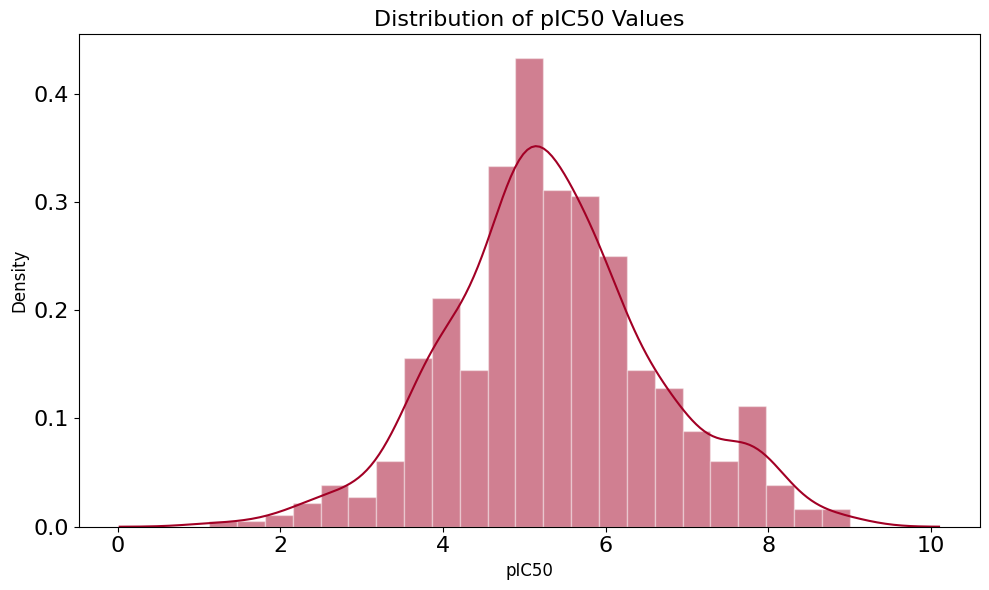

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(
    herg_blockers["pIC50"], kde=True,
    stat="density", kde_kws=dict(cut=3),
    edgecolor=(1, 1, 1, .4),
)
plt.title("Distribution of pIC50 Values", fontsize=16)
plt.xlabel("pIC50", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.tight_layout()
plt.savefig("./../figures/ch03/distribution_pic50.svg", bbox_inches='tight', dpi=600)
plt.savefig("./../figures/ch03/distribution_pic50.png", bbox_inches='tight', dpi=600)

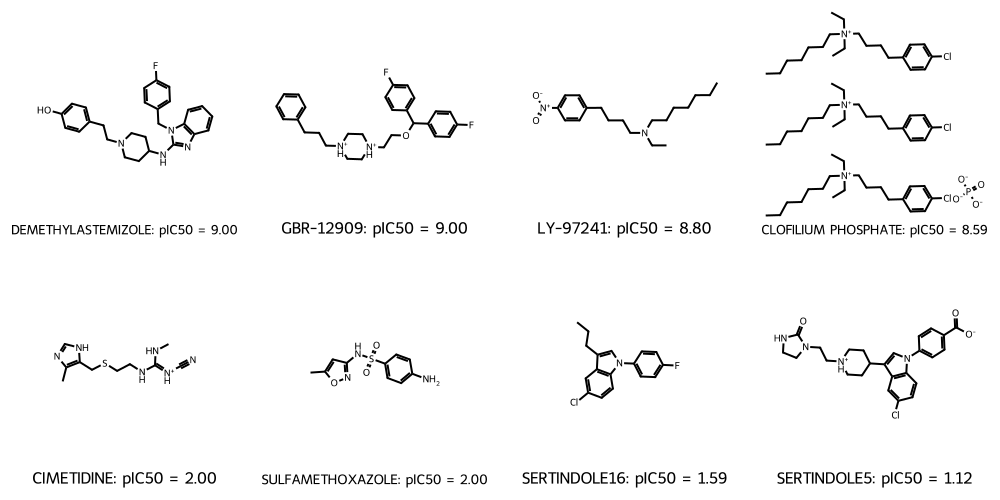

In [11]:
def visualize_extreme_molecules(df, activity_col="pIC50", name_col="Name", smiles_col="SMILES", n=4):
    """
    Visualize molecules with extreme activity values.
    
    Parameters:
        df (pandas.DataFrame): DataFrame containing the data
        activity_col (str): Column name with activity values
        name_col (str): Column name with compound names
        smiles_col (str): Column name with SMILES strings
        n (int): Number of molecules to show from each extreme
        
    Returns:
        rdkit.Chem.Draw._MolsToGridImage: Grid image of molecules
    """
    # Sort the dataframe by activity
    df_sorted = df.sort_values(activity_col, ascending=False)
    
    # Get the highest and lowest n molecules
    extremes = pd.concat([df_sorted.head(n), df_sorted.dropna().tail(n)])
    
    # Convert SMILES to molecules
    mols = [Chem.MolFromSmiles(smi) for smi in extremes[smiles_col]]
    
    # Create legends with name and activity
    legends = [
        f"{name}: pIC50 = {activity:.2f}" 
        for name, activity in zip(extremes[name_col], extremes[activity_col])
    ]
    
    # Create the visualization
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=n,
        subImgSize=(250, 250),
        legends=legends,
        useSVG=True,
        drawOptions=rdkit_drawing_options
    )
    
    # Save the image
    with open("./../figures/ch03/rdkit_extremes.svg", "w") as f:
        f.write(img.data)
    
    return img

# Visualize extreme molecules
extremes_img = visualize_extreme_molecules(herg_blockers)
display(extremes_img)


In [12]:
def process_smiles(smi):
    """
    Process SMILES strings to create standardized molecule objects.
    
    Args:
        smi (str): SMILES string representing a molecule
        
    Returns:
        rdkit.Chem.Mol: Standardized RDKit molecule object
    """
    # Convert SMILES to molecule
    mol = Chem.MolFromSmiles(smi)
    
    if mol is None:
        return None
    
    # Apply standardization steps
    mol = Cleanup(mol)  # Remove reactive groups, standardize bonds
    mol = LargestFragmentChooser().choose(mol)  # Select largest fragment (removes salts)
    mol = Uncharger().uncharge(mol)  # Neutralize charges where possible
    mol = TautomerEnumerator().Canonicalize(mol)  # Standardize tautomers
    
    return mol

# Apply standardization to all molecules in the dataset
herg_blockers["mol"] = herg_blockers["SMILES"].apply(process_smiles)

# Count non-standardizable molecules
invalid_mols = herg_blockers[herg_blockers["mol"].isna()]
if len(invalid_mols) > 0:
    print(f"Warning: {len(invalid_mols)} molecules could not be standardized.")
    herg_blockers = herg_blockers.dropna(subset=["mol"])

[20:06:26] Initializing MetalDisconnector
[20:06:26] Running MetalDisconnector
[20:06:26] Initializing Normalizer
[20:06:26] Running Normalizer
[20:06:26] Running LargestFragmentChooser
[20:06:26] Running Uncharger
[20:06:26] Initializing MetalDisconnector
[20:06:26] Running MetalDisconnector
[20:06:26] Initializing Normalizer
[20:06:26] Running Normalizer
[20:06:26] Running LargestFragmentChooser
[20:06:26] Running Uncharger
[20:06:26] Initializing MetalDisconnector
[20:06:26] Running MetalDisconnector
[20:06:26] Initializing Normalizer
[20:06:26] Running Normalizer
[20:06:26] Running LargestFragmentChooser
[20:06:26] Running Uncharger
[20:06:26] Initializing MetalDisconnector
[20:06:26] Running MetalDisconnector
[20:06:26] Initializing Normalizer
[20:06:26] Running Normalizer
[20:06:26] Running LargestFragmentChooser
[20:06:26] Fragment: CCCCCCC[N+](CC)(CC)CCCCc1ccc(Cl)cc1
[20:06:26] New largest fragment: CCCCCCC[N+](CC)(CC)CCCCc1ccc(Cl)cc1 (60)
[20:06:26] Fragment: CCCCCCC[N+](CC)(C

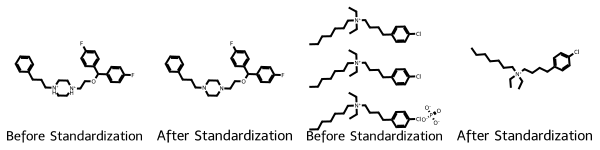

In [13]:
# Select a couple of examples to show before and after standardization
before_and_after_mols = [
    Chem.MolFromSmiles(herg_blockers.iloc[1].SMILES), 
    herg_blockers.iloc[1].mol, 
    Chem.MolFromSmiles(herg_blockers.iloc[3].SMILES), 
    herg_blockers.iloc[3].mol
]
legend_text = ["Before Standardization", "After Standardization"] * 2

# Create a grid of molecule visualizations
img = Draw.MolsToGridImage(
    before_and_after_mols, molsPerRow=4, subImgSize=(150, 150), 
    legends=legend_text, useSVG=True, drawOptions=rdkit_drawing_options,
)

# Save the visualization
with open("./../figures/ch03/rdkit_before_and_after.svg", "w") as f:
    f.write(img.data)

# Display the visualization
display(img)

In [14]:
from rdkit import DataStructs
from rdkit.Chem import AllChem

# Define function to compute Morgan fingerprints
def compute_fingerprint(mol, radius=2, nBits=2048):
    """Generate Morgan fingerprint for a molecule"""
    morgan_generator = GetMorganGenerator(radius=radius, fpSize=nBits)
    if mol is None:
        return None
    return morgan_generator.GetFingerprintAsNumPy(mol)

fingerprints = np.stack([compute_fingerprint(mol, 2, 2048) for mol in herg_blockers.mol])
fingerprints.shape

(587, 2048)

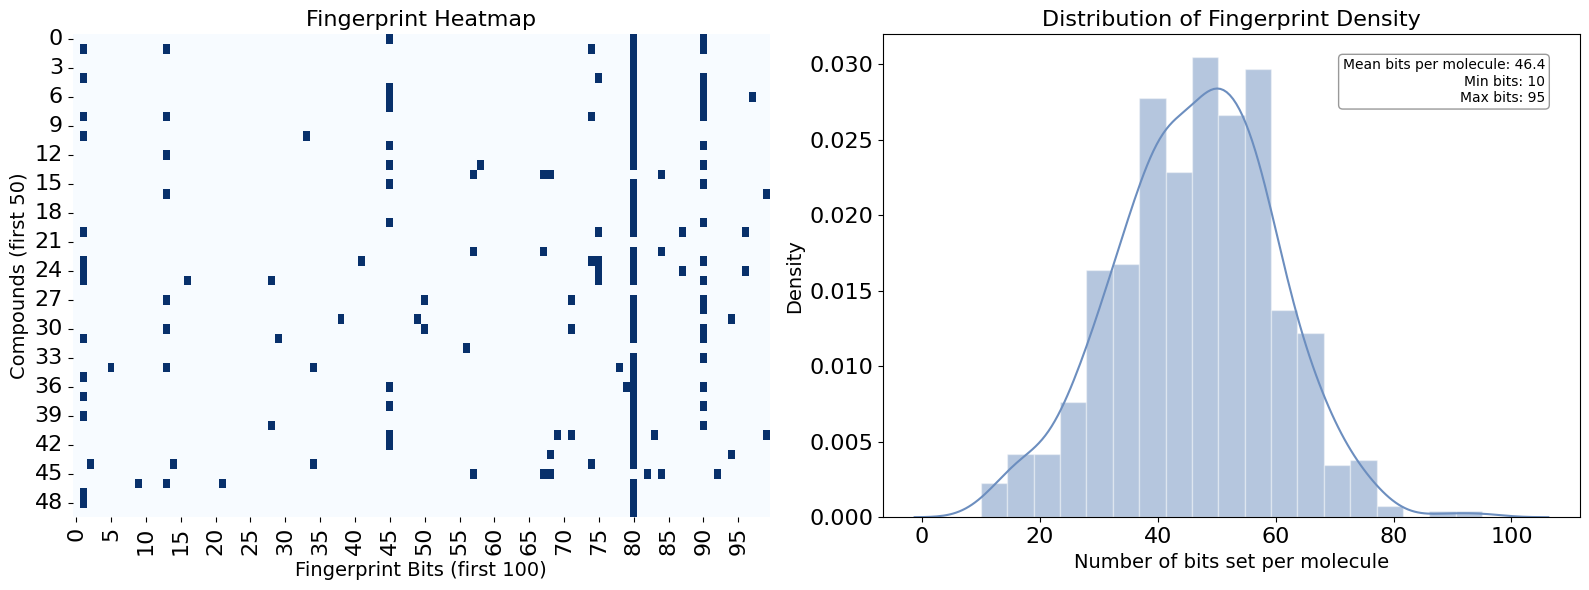

In [15]:
def explore_fingerprint_features(fingerprints):
    """
    Explore fingerprint features through visualizations.
    
    Parameters:
        fingerprints (numpy.ndarray): Array of fingerprints
        
    Returns:
        matplotlib.figure.Figure: Figure containing the visualizations
    """
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
    
    # Heatmap of fingerprints (first 50 compounds, first 100 bits)
    sns.heatmap(
        fingerprints[:50, :100],
        cbar=False,
        cmap="Blues",
        #cmap='Greys',
        ax=ax[0]
    )
    ax[0].set_xlabel("Fingerprint Bits (first 100)", fontsize=14)
    ax[0].set_ylabel("Compounds (first 50)", fontsize=14)
    ax[0].set_title("Fingerprint Heatmap", fontsize=16)
    
    # Distribution of bit counts per molecule
    bit_counts = fingerprints.sum(axis=1)
    sns.histplot(
        bit_counts,
        kde=True,
        stat="density",
        kde_kws=dict(cut=3),
        edgecolor=(1, 1, 1, .4),
        color="#6C8EBF",
        ax=ax[1]
    )
    ax[1].set_xlabel("Number of bits set per molecule", fontsize=14)
    ax[1].set_ylabel("Density", fontsize=14)
    ax[1].set_title("Distribution of Fingerprint Density", fontsize=16)
    
    # Add annotations about fingerprint statistics
    ax[1].annotate(
        f"Mean bits per molecule: {bit_counts.mean():.1f}\n"
        f"Min bits: {bit_counts.min()}\n"
        f"Max bits: {bit_counts.max()}",
        xy=(0.95, 0.95),
        xycoords='axes fraction',
        ha='right',
        va='top',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
    )
    
    plt.tight_layout()
    
    # Save the figure
    plt.savefig("./../figures/ch03/fingerprint_eda.svg", bbox_inches='tight', dpi=600)
    plt.savefig("./../figures/ch03/fingerprint_eda.png", bbox_inches='tight', dpi=600)
    
    return fig

# Explore fingerprint features
fp_fig = explore_fingerprint_features(fingerprints)

In [16]:
def split_data(df, split_col="Random Split", train_pattern="Train", test_pattern="Test"):
    """
    Split data into training and testing sets based on a split column.
    
    Parameters:
        df (pandas.DataFrame): DataFrame containing the data
        split_col (str): Column name with split information
        train_pattern (str): Pattern to identify training examples
        test_pattern (str): Pattern to identify test examples
        
    Returns:
        tuple: (train_df, test_df) DataFrames with training and testing data
    """
    # Extract indices for train and test sets
    train_mask = df[split_col].str.contains(train_pattern)
    test_mask = df[split_col].str.contains(test_pattern)
    
    # Create train and test dataframes
    train_df = df[train_mask].copy().reset_index(drop=True)
    test_df = df[test_mask].copy().reset_index(drop=True)
    
    # Shuffle the data
    train_df = train_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    test_df = test_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    
    print(f"Split data into {len(train_df)} training and {len(test_df)} testing examples")
    return train_df, test_df

train_set, test_set = split_data(herg_blockers)

Split data into 392 training and 195 testing examples


In [17]:
def train_sgd_classifier(X_train, y_train, **kwargs):
    """
    Train a Stochastic Gradient Descent classifier.
    
    Parameters:
        X_train (numpy.ndarray): Training features
        y_train (numpy.ndarray): Training labels
        **kwargs: Additional parameters for SGDClassifier
        
    Returns:
        sklearn.linear_model.SGDClassifier: Trained classifier
    """
    # Default parameters
    params = {
        'random_state': RANDOM_SEED,
        'max_iter': 1000,
        'tol': 1e-3
    }
    
    # Update with any provided parameters
    params.update(kwargs)
    
    # Create and train the classifier
    clf = SGDClassifier(**params)
    clf.fit(X_train, y_train)
    
    return clf

train_fingerprints = np.stack([compute_fingerprint(mol, 2, 2048) for mol in train_set.mol])
train_labels = train_set.Class

lin_cls = train_sgd_classifier(train_fingerprints, train_labels)

print("Linear model training completed")

# Show a sample of predictions
herg_blockers_pred = lin_cls.predict(train_fingerprints)
sample_size = min(10, len(herg_blockers_pred))
print(f"Sample of {sample_size} predictions: {herg_blockers_pred[:sample_size]}")
print(f"Sample of {sample_size} true labels: {train_labels[:sample_size].values}")

Linear model training completed
Sample of 10 predictions: [1 0 1 1 0 1 1 1 1 1]
Sample of 10 true labels: [1 0 1 1 0 1 1 1 1 1]


In [18]:
from sklearn.metrics import accuracy_score
accuracy_score(train_labels, herg_blockers_pred)

0.9642857142857143

In [19]:
from sklearn.model_selection import cross_validate

scoring = {'acc': 'accuracy'}
lin_cls_scores = cross_validate(lin_cls, train_fingerprints, train_labels, scoring=scoring, cv=5)
lin_cls_scores["test_acc"].mean()

0.7933463161311263

In [20]:
from sklearn.dummy import DummyClassifier

# Train a dummy classifier (most frequent strategy)
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy_clf.fit(train_fingerprints, train_labels)
accuracy_score(train_labels, dummy_clf.predict(train_fingerprints))

0.6938775510204082

In [21]:
from sklearn.metrics import confusion_matrix
confusion_matrix(train_labels, herg_blockers_pred)

array([[119,   1],
       [ 13, 259]])

In [22]:
scoring = {
  'acc': 'accuracy',
  'prec_macro': 'precision',
  'rec_macro': 'recall',
  'f1_macro': 'f1',
}
lin_cls_scores = cross_validate(lin_cls, train_fingerprints, train_labels, scoring=scoring, cv=5, return_train_score=True)
lin_cls_scores_df = pd.DataFrame.from_dict(lin_cls_scores)
lin_cls_scores_df.describe().round(3)

,fit_time,score_time,test_acc,train_acc,test_prec_macro,train_prec_macro,test_rec_macro,train_rec_macro,test_f1_macro,train_f1_macro
count,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000
mean,0.037,0.012,0.793,0.978,0.861,0.992,0.845,0.977,0.850,0.984
std,0.015,0.000,0.038,0.008,0.060,0.006,0.066,0.013,0.028,0.006
min,0.023,0.012,0.744,0.965,0.804,0.986,0.741,0.954,0.818,0.974
25%,0.028,0.012,0.782,0.978,0.817,0.986,0.833,0.977,0.825,0.984
50%,0.031,0.012,0.785,0.981,0.833,0.991,0.852,0.982,0.852,0.986
75%,0.044,0.012,0.810,0.981,0.920,0.995,0.891,0.986,0.870,0.986
max,0.060,0.013,0.846,0.987,0.930,1.000,0.909,0.986,0.885,0.991


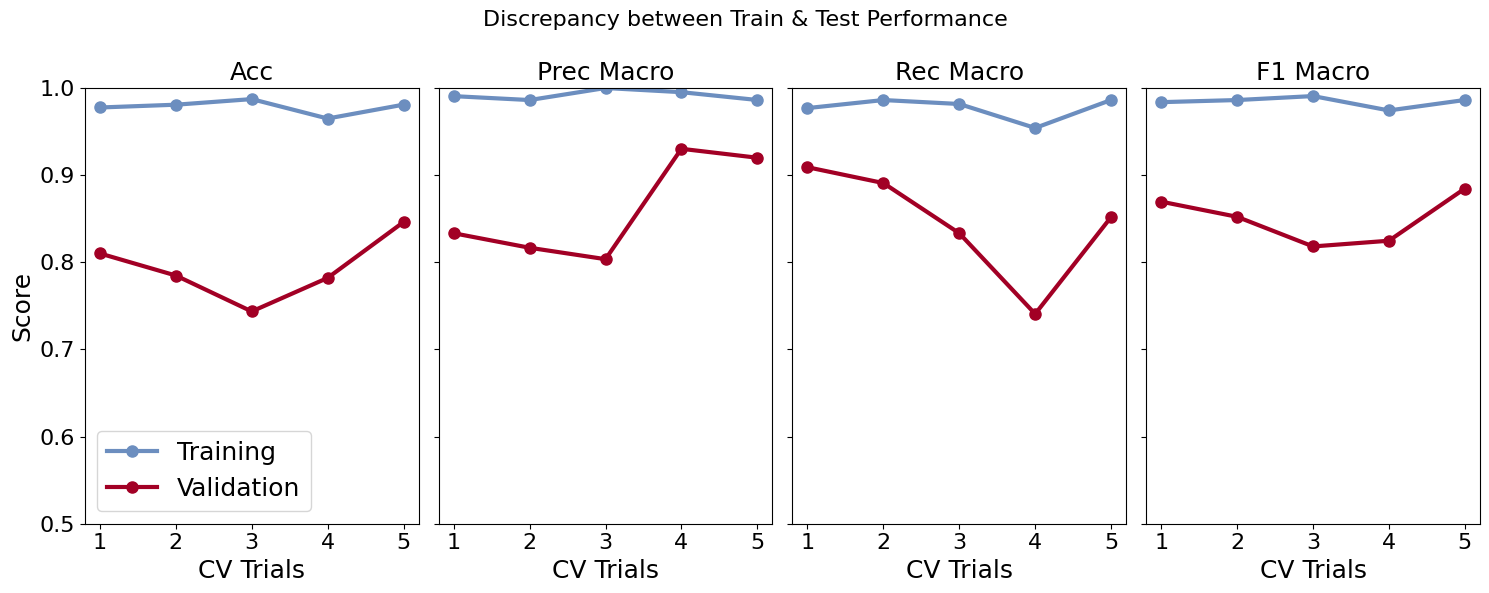

In [23]:
def visualize_cv_results(cv_df):
    """
    Visualize cross-validation results.
    
    Parameters:
        cv_df (pandas.DataFrame): DataFrame with cross-validation results
        
    Returns:
        matplotlib.figure.Figure: Figure with visualization
    """
    # Extract metric names
    metrics = [col.split('_', 1)[1] for col in cv_df.columns if col.startswith('test_')]
    
    # Create a subplot for each metric
    fig, axes = plt.subplots(1, len(metrics), figsize=(15, 6), sharey=True)
    fig.suptitle("Discrepancy between Train & Test Performance", fontsize=16)
    
    # Set y-axis limits for all subplots
    ylim = (0.5, 1.0)
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        # Get train and test scores for this metric
        train_scores = cv_df[f'train_{metric}']
        test_scores = cv_df[f'test_{metric}']
        
        # Plot the scores
        x = range(1, len(train_scores) + 1)
        ax.plot(x, train_scores, 'o-', label='Training', color='#6C8EBF', linewidth=3, markersize=8)
        ax.plot(x, test_scores, 'o-', label='Validation', color='#A20025', linewidth=3, markersize=8)
        
        # Set labels and title
        ax.set_title(metric.replace('_', ' ').title(), fontsize=18)
        ax.set_xlabel('CV Trials', fontsize=18)
        if i == 0:
            ax.set_ylabel('Score', fontsize=18)
        
        # Set x-ticks
        ax.set_xticks(x)
        
        # Set y-axis limits
        ax.set_ylim(ylim)
        
        # Add legend only to the first subplot
        if i == 0:
            ax.legend(fontsize=18)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    
    # Save the figure
    plt.savefig('./../figures/ch03/cv_metrics_discrepancy.svg', bbox_inches='tight', dpi=600)
    plt.savefig('./../figures/ch03/cv_metrics_discrepancy.png', bbox_inches='tight', dpi=600)
    
    return fig

cv_fig = visualize_cv_results(lin_cls_scores_df)

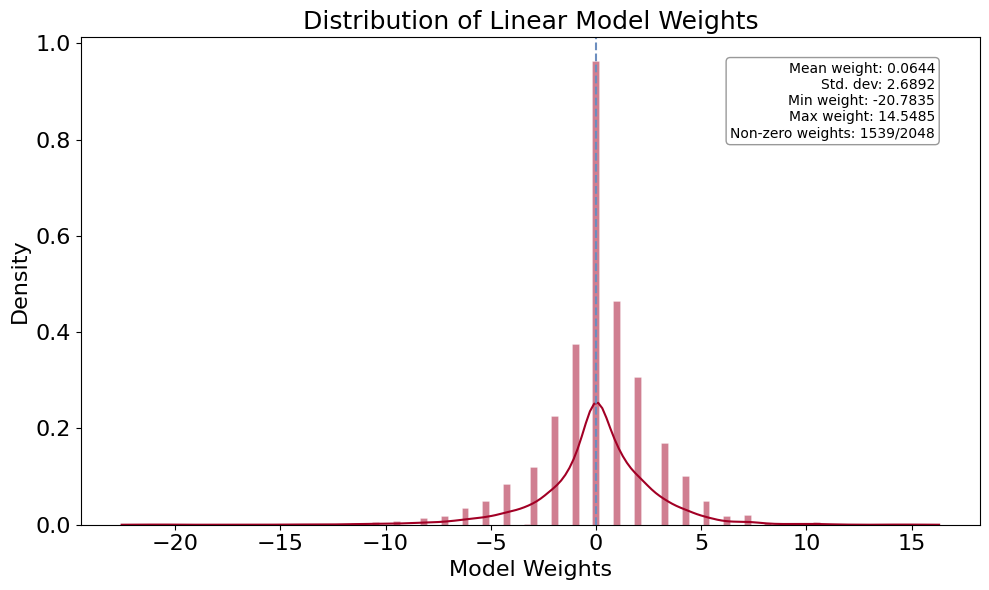

In [24]:
def visualize_model_weights(model):
    """
    Visualize the distribution of weights in a linear model.
    
    Parameters:
        model (object): Trained linear model with coef_ attribute
        
    Returns:
        matplotlib.figure.Figure: Figure with visualization
    """
    # Extract weights from the model or pipeline
    if hasattr(model, 'named_steps') and 'sgdclassifier' in model.named_steps:
        weights = model.named_steps['sgdclassifier'].coef_.squeeze()
    else:
        weights = model.coef_.squeeze()
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    
    # Plot histogram with KDE
    sns.histplot(
        weights,
        kde=True,
        stat="density",
        kde_kws=dict(cut=3),
        edgecolor=(1, 1, 1, .4),
        color="#A20025",
    )
    
    # Add annotations about weight statistics
    plt.annotate(
        f"Mean weight: {weights.mean():.4f}\n"
        f"Std. dev: {weights.std():.4f}\n"
        f"Min weight: {weights.min():.4f}\n"
        f"Max weight: {weights.max():.4f}\n"
        f"Non-zero weights: {np.count_nonzero(weights)}/{len(weights)}",
        xy=(0.95, 0.95),
        xycoords='axes fraction',
        ha='right',
        va='top',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
    )
    
    # Add vertical line at zero
    plt.axvline(x=0, color='#6C8EBF', linestyle='--')
    
    plt.xlabel("Model Weights")
    plt.ylabel("Density")
    plt.title("Distribution of Linear Model Weights")
    
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('./../figures/ch03/model_weights_displot.svg', bbox_inches='tight', dpi=600)
    plt.savefig('./../figures/ch03/model_weights_displot.png', bbox_inches='tight', dpi=600)
    
    return plt.gcf()

# Visualize model weights
weights_fig = visualize_model_weights(lin_cls)

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline, Pipeline

class SmilesToMols(BaseEstimator, TransformerMixin):
    """Transformer that converts SMILES strings to RDKit molecules."""
    
    def fit(self, X, y=None):
        return self
    
    def _process_smiles(self, smi):
        """Process a SMILES string to create a standardized molecule."""
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                return None
            
            mol = Cleanup(mol)
            mol = LargestFragmentChooser().choose(mol)
            mol = Uncharger().uncharge(mol)
            mol = TautomerEnumerator().Canonicalize(mol)
            
            return mol
        except Exception as e:
            print(f"Error processing SMILES {smi}: {str(e)}")
            return None
    
    def transform(self, X, y=None):
        """Transform SMILES strings to RDKit molecules."""
        print("Converting SMILES to molecules...")
        mols = [self._process_smiles(smi) for smi in X]
        return np.asarray(mols, dtype=object)

class FingerprintFeaturizer(BaseEstimator, TransformerMixin):
    """Transformer that converts RDKit molecules to fingerprints."""
    
    def __init__(self, radius=2, nBits=2048):
        self.radius = radius
        self.nBits = nBits
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        """Transform molecules to fingerprints."""
        print(f"Generating fingerprints (radius={self.radius}, nBits={self.nBits})...")
        
        from rdkit import DataStructs
        
        # Function to compute fingerprint for a single molecule
        def compute_fp(mol):
            if mol is None:
                return np.zeros(self.nBits, dtype=np.int8)
            
            morgan_generator = GetMorganGenerator(radius=self.radius, fpSize=self.nBits)
            return morgan_generator.GetFingerprintAsNumPy(mol)
        
        # Apply to all molecules
        fingerprints = [compute_fp(mol) for mol in X]
        return np.vstack(fingerprints)

In [27]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import joblib

def tune_model_hyperparameters(X, y, n_iter=20, cv=5):
    """
    Tune model hyperparameters using grid search.
    
    Parameters:
        X (array-like): Features
        y (array-like): Labels
        n_iter (int): Number of iterations for randomized search
        cv (int): Number of cross-validation folds
        
    Returns:
        tuple: (best_estimator, cv_results_df) The best estimator and CV results
    """
    # Create a temporary cache directory
    cachedir = "gs_linear_sgd"

    # Create the pipeline
    pipe = make_pipeline(
        SmilesToMols(),
        FingerprintFeaturizer(),
        SGDClassifier(random_state=RANDOM_SEED),
        memory=cachedir
    )
    
    # Define parameter grid
    param_grid = [{
        'sgdclassifier__penalty': ["l2", "l1"],
        'sgdclassifier__alpha': [1e-3, 1e-2, 1e-1],
        'fingerprintfeaturizer__radius': [2, 4],
        'fingerprintfeaturizer__nBits': [1024, 2048],
    }]
        
    # Determine which search method to use
    print("Performing grid search for hyperparameter tuning...")
    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        verbose=1,
    )

    # Perform the search
    search.fit(X, y)
    
    # Extract results
    print(f"Best parameters: {search.best_params_}")
    print(f"Best score: {search.best_score_:.4f}")
    
    # Convert results to DataFrame
    cv_results_df = pd.DataFrame(search.cv_results_)
    
    return search.best_estimator_, cv_results_df

X_smiles = herg_blockers['SMILES'].values
y_labels = herg_blockers['Class'].values

# Tune the model
best_model_gs, cv_results = tune_model_hyperparameters(X_smiles, y_labels)

# Save the best model
joblib.dump(best_model_gs, "./../artifacts/ch03/herg_blockers_cls_model.pkl")
print("Best model saved to './../artifacts/ch03/herg_blockers_cls_model.pkl'")

Performing grid search for hyperparameter tuning...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Converting SMILES to molecules...


[20:17:28] Initializing MetalDisconnector
[20:17:28] Running MetalDisconnector
[20:17:28] Initializing Normalizer
[20:17:28] Running Normalizer
[20:17:28] Running LargestFragmentChooser
[20:17:28] Running Uncharger
[20:17:28] Initializing MetalDisconnector
[20:17:28] Running MetalDisconnector
[20:17:28] Initializing Normalizer
[20:17:28] Running Normalizer
[20:17:28] Running LargestFragmentChooser
[20:17:28] Running Uncharger
[20:17:28] Initializing MetalDisconnector
[20:17:28] Running MetalDisconnector
[20:17:28] Initializing Normalizer
[20:17:28] Running Normalizer
[20:17:28] Running LargestFragmentChooser
[20:17:28] Running Uncharger
[20:17:28] Initializing MetalDisconnector
[20:17:28] Running MetalDisconnector
[20:17:28] Initializing Normalizer
[20:17:28] Running Normalizer
[20:17:28] Running LargestFragmentChooser
[20:17:28] Fragment: CCCCCCC[N+](CC)(CC)CCCCc1ccc(Cl)cc1
[20:17:28] New largest fragment: CCCCCCC[N+](CC)(CC)CCCCc1ccc(Cl)cc1 (60)
[20:17:28] Fragment: CCCCCCC[N+](CC)(C

Generating fingerprints (radius=2, nBits=1024)...
Converting SMILES to molecules...


[20:17:29] Initializing MetalDisconnector
[20:17:29] Running MetalDisconnector
[20:17:29] Initializing Normalizer
[20:17:29] Running Normalizer
[20:17:29] Running LargestFragmentChooser
[20:17:29] Running Uncharger
[20:17:29] Initializing MetalDisconnector
[20:17:29] Running MetalDisconnector
[20:17:29] Initializing Normalizer
[20:17:29] Running Normalizer
[20:17:29] Running LargestFragmentChooser
[20:17:29] Running Uncharger
[20:17:29] Initializing MetalDisconnector
[20:17:29] Running MetalDisconnector
[20:17:29] Initializing Normalizer
[20:17:29] Running Normalizer
[20:17:29] Running LargestFragmentChooser
[20:17:29] Running Uncharger
[20:17:29] Initializing MetalDisconnector
[20:17:29] Running MetalDisconnector
[20:17:29] Initializing Normalizer
[20:17:29] Running Normalizer
[20:17:29] Running LargestFragmentChooser
[20:17:29] Running Uncharger
[20:17:29] Initializing MetalDisconnector
[20:17:29] Running MetalDisconnector
[20:17:29] Initializing Normalizer
[20:17:29] Running Normali

Generating fingerprints (radius=2, nBits=1024)...
Converting SMILES to molecules...


...

Generating fingerprints (radius=4, nBits=2048)...
Converting SMILES to molecules...


[20:21:08] Initializing MetalDisconnector
[20:21:08] Running MetalDisconnector
[20:21:08] Initializing Normalizer
[20:21:08] Running Normalizer
[20:21:08] Running LargestFragmentChooser
[20:21:08] Running Uncharger
[20:21:08] Removed positive charge.
[20:21:08] Initializing MetalDisconnector
[20:21:08] Running MetalDisconnector
[20:21:08] Initializing Normalizer
[20:21:08] Running Normalizer
[20:21:08] Running LargestFragmentChooser
[20:21:08] Running Uncharger
[20:21:08] Initializing MetalDisconnector
[20:21:08] Running MetalDisconnector
[20:21:08] Initializing Normalizer
[20:21:08] Running Normalizer
[20:21:08] Running LargestFragmentChooser
[20:21:08] Running Uncharger
[20:21:08] Initializing MetalDisconnector
[20:21:08] Running MetalDisconnector
[20:21:08] Initializing Normalizer
[20:21:08] Running Normalizer
[20:21:08] Running LargestFragmentChooser
[20:21:08] Running Uncharger
[20:21:08] Initializing MetalDisconnector
[20:21:08] Running MetalDisconnector
[20:21:08] Initializing N

Generating fingerprints (radius=4, nBits=2048)...
Converting SMILES to molecules...


[20:21:11] Initializing MetalDisconnector
[20:21:11] Running MetalDisconnector
[20:21:11] Initializing Normalizer
[20:21:11] Running Normalizer
[20:21:11] Running LargestFragmentChooser
[20:21:11] Running Uncharger
[20:21:11] Initializing MetalDisconnector
[20:21:11] Running MetalDisconnector
[20:21:11] Initializing Normalizer
[20:21:11] Running Normalizer
[20:21:11] Running LargestFragmentChooser
[20:21:11] Running Uncharger
[20:21:11] Removed negative charge.
[20:21:11] Removed positive charge.
[20:21:11] Initializing MetalDisconnector
[20:21:11] Running MetalDisconnector
[20:21:11] Initializing Normalizer
[20:21:11] Running Normalizer
[20:21:11] Running LargestFragmentChooser
[20:21:11] Running Uncharger
[20:21:11] Initializing MetalDisconnector
[20:21:11] Running MetalDisconnector
[20:21:11] Initializing Normalizer
[20:21:11] Running Normalizer
[20:21:11] Running LargestFragmentChooser
[20:21:11] Running Uncharger
[20:21:11] Initializing MetalDisconnector
[20:21:11] Running MetalDi

Generating fingerprints (radius=4, nBits=2048)...
Best parameters: {'fingerprintfeaturizer__nBits': 2048, 'fingerprintfeaturizer__radius': 2, 'sgdclassifier__alpha': 0.01, 'sgdclassifier__penalty': 'l1'}
Best score: 0.8516
Best model saved to './../artifacts/ch03/herg_blockers_cls_model.pkl'


In [28]:
# Display top results
top_results = cv_results.sort_values('mean_test_score', ascending=False).head(5)
print("Top 5 parameter combinations:")
with pd.option_context('display.max_colwidth', None, 'display.width', None):
    display(top_results[['params', 'mean_test_score', 'std_test_score']])

Top 5 parameter combinations:


,params,mean_test_score,std_test_score
15,"{'fingerprintfeaturizer__nBits': 2048, 'fingerprintfeaturizer__radius': 2, 'sgdclassifier__alpha': 0.01, 'sgdclassifier__penalty': 'l1'}",0.851563,0.026940
3,"{'fingerprintfeaturizer__nBits': 1024, 'fingerprintfeaturizer__radius': 2, 'sgdclassifier__alpha': 0.01, 'sgdclassifier__penalty': 'l1'}",0.851422,0.021919
9,"{'fingerprintfeaturizer__nBits': 1024, 'fingerprintfeaturizer__radius': 4, 'sgdclassifier__alpha': 0.01, 'sgdclassifier__penalty': 'l1'}",0.849858,0.041465
21,"{'fingerprintfeaturizer__nBits': 2048, 'fingerprintfeaturizer__radius': 4, 'sgdclassifier__alpha': 0.01, 'sgdclassifier__penalty': 'l1'}",0.849098,0.023591
16,"{'fingerprintfeaturizer__nBits': 2048, 'fingerprintfeaturizer__radius': 2, 'sgdclassifier__alpha': 0.1, 'sgdclassifier__penalty': 'l2'}",0.847988,0.014627


In [29]:
def tune_model_hyperparameters_randomized_search(X, y, n_iter=20, cv=5):
    """
    Tune model hyperparameters using grid search.
    
    Parameters:
        X (array-like): Features
        y (array-like): Labels
        n_iter (int): Number of iterations for randomized search
        cv (int): Number of cross-validation folds
        
    Returns:
        tuple: (best_estimator, cv_results_df) The best estimator and CV results
    """
    # Create a temporary cache directory
    cachedir = "rs_nonlinear_sgd"

    # Create the pipeline
    pipe = make_pipeline(
        FingerprintFeaturizer(),  # Transformer: Feature generation step
        PolynomialFeatures(degree=2, include_bias=False, interaction_only=True),  # Transformer: Nonlinear feature transform
        SGDClassifier(max_iter=5000, random_state=RANDOM_SEED, early_stopping=True),  # Estimator: SGDClassifier (Logistic Regressor)
        memory=cachedir
    )
    
    # Define parameter distribution
    param_dist = [{
        'sgdclassifier__penalty': ["l2", "l1"],
        'sgdclassifier__alpha': sp_rand(0.01),
        'fingerprintfeaturizer__radius': [2, 4],
        'fingerprintfeaturizer__nBits': [64, 128, 256],
    }]
        
    # Determine which search method to use
    print("Performing randomized search for hyperparameter tuning...")
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        scoring="f1",
        cv=cv,
        n_iter=n_iter,
    )

    # Perform the search
    search.fit(X, y)
    
    # Extract results
    print(f"Best parameters: {search.best_params_}")
    print(f"Best score: {search.best_score_:.4f}")
    
    # Convert results to DataFrame
    cv_results_df = pd.DataFrame(search.cv_results_)
    
    return search.best_estimator_, cv_results_df

# Tune the model
best_model_rs, cv_results_rs = tune_model_hyperparameters_randomized_search(train_set.mol, train_set.Class)

# Save the best model
joblib.dump(best_model_rs, "./../artifacts/ch03/herg_blockers_cls_model_rs.pkl")
print("Best model saved to './../artifacts/ch03/herg_blockers_cls_model_rs.pkl'")

Performing randomized search for hyperparameter tuning...
Generating fingerprints (radius=4, nBits=256)...
Generating fingerprints (radius=4, nBits=256)...
Generating fingerprints (radius=4, nBits=256)...
Generating fingerprints (radius=4, nBits=256)...
Generating fingerprints (radius=4, nBits=256)...
Generating fingerprints (radius=4, nBits=256)...
Generating fingerprints (radius=4, nBits=256)...
Generating fingerprints (radius=4, nBits=256)...
Generating fingerprints (radius=4, nBits=256)...
Generating fingerprints (radius=4, nBits=256)...
Generating fingerprints (radius=2, nBits=64)...
Generating fingerprints (radius=2, nBits=64)...
Generating fingerprints (radius=2, nBits=64)...
Generating fingerprints (radius=2, nBits=64)...
Generating fingerprints (radius=2, nBits=64)...
Generating fingerprints (radius=2, nBits=64)...
Generating fingerprints (radius=2, nBits=64)...
Generating fingerprints (radius=2, nBits=64)...
Generating fingerprints (radius=2, nBits=64)...
Generating fingerpri

/data/home/aboussif/venv/lib/python3.11/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters: {'fingerprintfeaturizer__nBits': 256, 'fingerprintfeaturizer__radius': 2, 'sgdclassifier__alpha': 0.46924889196586717, 'sgdclassifier__penalty': 'l2'}
Best score: 0.8511
Best model saved to './../artifacts/ch03/herg_blockers_cls_model_rs.pkl'


In [30]:
# Display top results
top_results_rs = cv_results_rs.sort_values('mean_test_score', ascending=False).head(5)
print("Top 5 parameter combinations:")
with pd.option_context('display.max_colwidth', None, 'display.width', None):
    display(top_results_rs[['params', 'mean_test_score', 'std_test_score']])

Top 5 parameter combinations:


,params,mean_test_score,std_test_score
2,"{'fingerprintfeaturizer__nBits': 256, 'fingerprintfeaturizer__radius': 2, 'sgdclassifier__alpha': 0.46924889196586717, 'sgdclassifier__penalty': 'l2'}",0.851126,0.036311
10,"{'fingerprintfeaturizer__nBits': 64, 'fingerprintfeaturizer__radius': 2, 'sgdclassifier__alpha': 0.8699404067363206, 'sgdclassifier__penalty': 'l2'}",0.831946,0.018115
3,"{'fingerprintfeaturizer__nBits': 256, 'fingerprintfeaturizer__radius': 4, 'sgdclassifier__alpha': 0.06641157902710025, 'sgdclassifier__penalty': 'l1'}",0.831938,0.017094
1,"{'fingerprintfeaturizer__nBits': 64, 'fingerprintfeaturizer__radius': 2, 'sgdclassifier__alpha': 0.16601864044243653, 'sgdclassifier__penalty': 'l2'}",0.830053,0.049026
18,"{'fingerprintfeaturizer__nBits': 64, 'fingerprintfeaturizer__radius': 2, 'sgdclassifier__alpha': 0.8522847745949985, 'sgdclassifier__penalty': 'l1'}",0.819267,0.001329


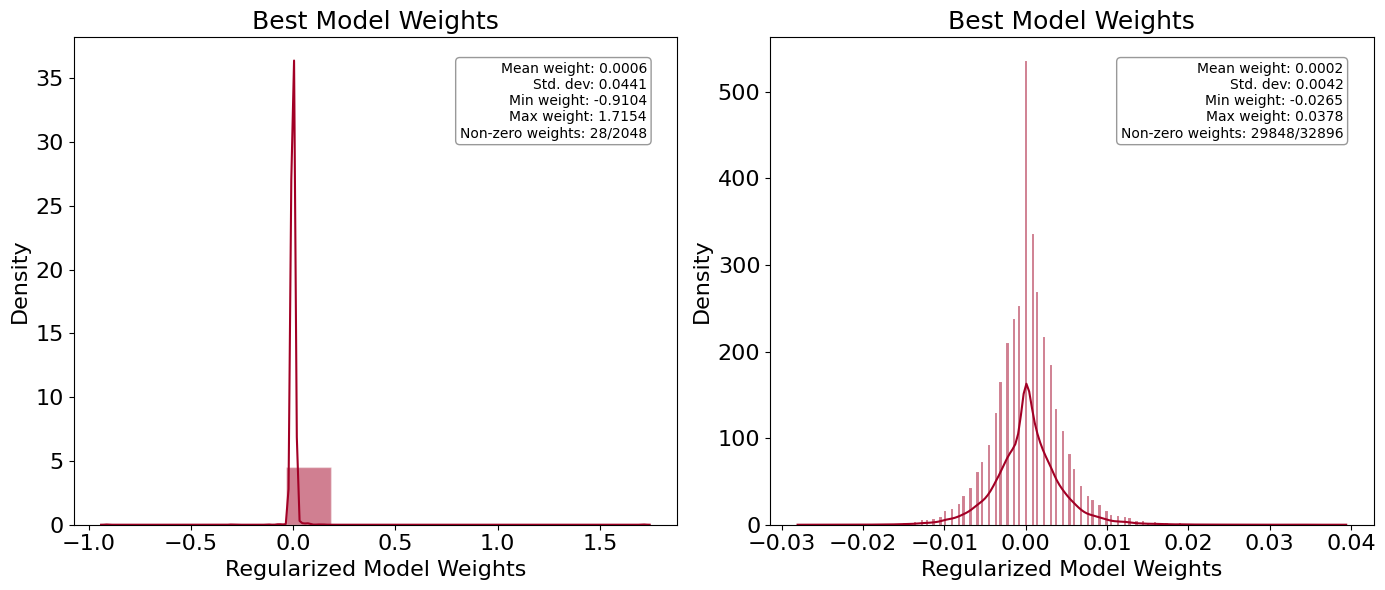

In [31]:
# Extract model weights from both models
best_model_gs_weights = best_model_gs.named_steps["sgdclassifier"].coef_.squeeze()
best_model_rs_weights = best_model_rs.named_steps["sgdclassifier"].coef_.squeeze()

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for final model
sns.histplot(
    best_model_gs_weights, kde=True,
    stat="density", kde_kws=dict(cut=3),
    edgecolor=(1, 1, 1, .4),
    ax=axes[0]
)
axes[0].set_title("Best Model Weights")
axes[0].set_xlabel("Regularized Model Weights")

# Plot for best model
sns.histplot(
    best_model_rs_weights, kde=True,
    stat="density", kde_kws=dict(cut=3),
    edgecolor=(1, 1, 1, .4),
    ax=axes[1]
)
axes[1].set_title("Best Model Weights")
axes[1].set_xlabel("Regularized Model Weights")

# Add annotations for final model
axes[0].annotate(
    f"Mean weight: {best_model_gs_weights.mean():.4f}\n"
    f"Std. dev: {best_model_gs_weights.std():.4f}\n"
    f"Min weight: {best_model_gs_weights.min():.4f}\n"
    f"Max weight: {best_model_gs_weights.max():.4f}\n"
    f"Non-zero weights: {np.count_nonzero(best_model_gs_weights)}/{len(best_model_gs_weights)}",
    xy=(0.95, 0.95),
    xycoords='axes fraction',
    ha='right',
    va='top',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

# Add annotations for best model
axes[1].annotate(
    f"Mean weight: {best_model_rs_weights.mean():.4f}\n"
    f"Std. dev: {best_model_rs_weights.std():.4f}\n"
    f"Min weight: {best_model_rs_weights.min():.4f}\n"
    f"Max weight: {best_model_rs_weights.max():.4f}\n"
    f"Non-zero weights: {np.count_nonzero(best_model_rs_weights)}/{len(best_model_rs_weights)}",
    xy=(0.95, 0.95),
    xycoords='axes fraction',
    ha='right',
    va='top',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

plt.tight_layout()
plt.savefig("./../figures/ch03/regularized_model_weights_comparison.svg", bbox_inches='tight', dpi=600)
plt.savefig("./../figures/ch03/regularized_model_weights_comparison.png", bbox_inches='tight', dpi=600)

In [32]:
important_bits = np.argwhere(best_model_gs_weights).flatten()
important_bits.shape

(28,)

In [33]:
N = 3

top_ind_unsorted = np.argpartition(best_model_gs_weights, -N)[-N:]
top_ind_sorted = top_ind_unsorted[np.argsort(best_model_gs_weights[top_ind_unsorted])[::-1]]

bot_ind_unsorted = np.argpartition(best_model_gs_weights, N)[:N]
bot_ind_sorted = bot_ind_unsorted[np.argsort(best_model_gs_weights[bot_ind_unsorted])]

print(top_ind_sorted)
print(bot_ind_sorted)

top_bit_coefficients = best_model_gs_weights[top_ind_sorted]
bot_bit_coefficients = best_model_gs_weights[bot_ind_sorted]

print(top_bit_coefficients)
print(bot_bit_coefficients)

[1750 1088 1873]
[1294 1164    9]
[1.71541113 0.14600836 0.12425778]
[-0.91039625 -0.3011597  -0.1208204 ]


In [34]:
def draw_fragment_from_bit(mol, bit_number):
  """ Given an rdkit mol, draws the local fragment that corresponds to the set bit of ecfp featurization.

  If the bit is not set, will throw an error.
  """
  ao = AdditionalOutput()
  ao.AllocateBitInfoMap()
  morgan_generator = GetMorganGenerator(radius=2, fpSize=2048)
  fp = morgan_generator.GetFingerprint(mol, additionalOutput=ao)
  try:
    svg = Draw.DrawMorganBit(mol, bit_number, ao.GetBitInfoMap(), useSVG=True)
  except:
    raise ValueError(f"Featurization of mol doesn't have bit {bit_number} set")
  return svg

def get_examples_for_bit(bit_number, mols, fingerprints):
  """ For a given bit number, get a visual representation of what substructure it represents"""
  res = np.argwhere(fingerprints[:, bit_number] == 1)
  mols = np.array(mols)[res.flatten()]
  return [draw_fragment_from_bit(mols[i], bit_number) for i in range(len(mols))]

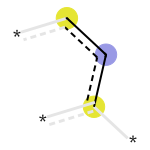

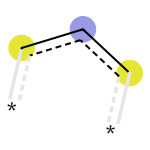

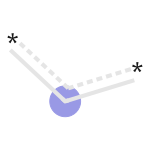

In [35]:
for i, bit in enumerate(top_ind_sorted):
  examples = get_examples_for_bit(bit, train_set.mol, train_fingerprints)
  with open(f"./../figures/ch03/top_example_bit{i}.svg", "w") as f:
    f.write(examples[0].data)
  display(examples[0])

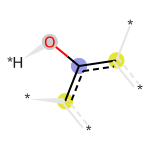

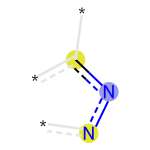

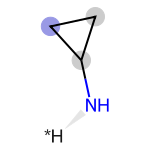

In [36]:
for i, bit in enumerate(bot_ind_sorted):
  examples = get_examples_for_bit(bit, train_set.mol, train_fingerprints)
  with open(f"./../figures/ch03/bot_example_bit{i}.svg", "w") as f:
    f.write(examples[0].data)
  display(examples[0])

In [37]:
def evaluate_final_model(model, X_test, y_test, output_file=None):
    """
    Evaluate the final model on the test set.
    
    Parameters:
        model (object): Trained model
        X_test (array-like): Test features
        y_test (array-like): Test labels
        output_file (str): Path to save evaluation results
        
    Returns:
        dict: Dictionary with evaluation metrics
    """
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    f1 = f1_score(y_test, y_pred, average='macro')
    matthews_cc = matthews_corrcoef(y_test, y_pred)
    
    # Create a report
    report = (
        f"Final Model Evaluation on Test Set\n"
        f"==================================\n"
        f"F1 Score (macro): {f1:.4f}\n"
        f"\nMatthews Correlation Coefficient:\n{matthews_cc:.4f}\n"
    )
    
    # Print the report
    print(report)
    
    # Save the report if requested
    if output_file:
        with open(output_file, 'w') as f:
            f.write(report)
        print(f"Evaluation report saved to {output_file}")
    
    return {
        'f1_score': f1,
        'matthews_corrcoef': matthews_cc,
        'predictions': y_pred
    }

# Evaluate our final model on the test set
X_test_smiles = test_set['SMILES'].values
y_test = test_set['Class'].values

final_metrics = evaluate_final_model(
    best_model_gs,
    X_test_smiles,
    y_test,
    output_file="./../artifacts/ch03/final_model_evaluation.txt"
)

Converting SMILES to molecules...


[20:23:43] Initializing MetalDisconnector
[20:23:43] Running MetalDisconnector
[20:23:43] Initializing Normalizer
[20:23:43] Running Normalizer
[20:23:43] Running LargestFragmentChooser
[20:23:43] Fragment: CN(C)CCCN1c2ccccc2CCc2ccc(Cl)cc21
[20:23:43] New largest fragment: CN(C)CCCN1c2ccccc2CCc2ccc(Cl)cc21 (45)
[20:23:43] Fragment: CCN(CC)CCOC(=O)c1ccc(N)cc1
[20:23:43] Running Uncharger
[20:23:43] Initializing MetalDisconnector
[20:23:43] Running MetalDisconnector
[20:23:43] Initializing Normalizer
[20:23:43] Running Normalizer
[20:23:43] Running LargestFragmentChooser
[20:23:43] Running Uncharger
[20:23:43] Initializing MetalDisconnector
[20:23:43] Running MetalDisconnector
[20:23:43] Initializing Normalizer
[20:23:43] Running Normalizer
[20:23:43] Running LargestFragmentChooser
[20:23:43] Running Uncharger
[20:23:43] Initializing MetalDisconnector
[20:23:43] Running MetalDisconnector
[20:23:43] Initializing Normalizer
[20:23:43] Running Normalizer
[20:23:43] Running LargestFragmentCh

Generating fingerprints (radius=2, nBits=2048)...
Final Model Evaluation on Test Set
F1 Score (macro): 0.7016

Matthews Correlation Coefficient:
0.4328

Evaluation report saved to ./../artifacts/ch03/final_model_evaluation.txt


[20:23:45] Initializing MetalDisconnector
[20:23:45] Running MetalDisconnector
[20:23:45] Initializing Normalizer
[20:23:45] Running Normalizer
[20:23:45] Running LargestFragmentChooser
[20:23:45] Running Uncharger
[20:23:45] Initializing MetalDisconnector
[20:23:45] Running MetalDisconnector
[20:23:45] Initializing Normalizer
[20:23:45] Running Normalizer
[20:23:45] Running LargestFragmentChooser
[20:23:45] Running Uncharger
[20:23:45] Initializing MetalDisconnector
[20:23:45] Running MetalDisconnector
[20:23:45] Initializing Normalizer
[20:23:45] Running Normalizer
[20:23:45] Running LargestFragmentChooser
[20:23:45] Fragment: O=C(O)[C@H](O)[C@@H](O)[C@H]1O[SbH]O[C@@H]1CO
[20:23:45] New largest fragment: O=C(O)[C@H](O)[C@@H](O)[C@H]1O[SbH]O[C@@H]1CO (25)
[20:23:45] Fragment: O
[20:23:45] Running Uncharger
[20:23:45] Initializing MetalDisconnector
[20:23:45] Running MetalDisconnector
[20:23:45] Initializing Normalizer
[20:23:45] Running Normalizer
[20:23:45] Running LargestFragmentCho

In [43]:
import os
def save_load_model_demo(model_path="./../artifacts/ch03/herg_blockers_cls_model.pkl"):
    """
    Demonstrate how to save and load a model.
    
    Parameters:
        model_path (str): Path to the saved model
        
    Returns:
        object: Loaded model
    """
    # Import statements that would be needed in a new script
    demonstration_code = """
# Required imports for loading and using the model
import joblib
from rdkit import Chem
from rdkit.Chem import MolStandardize, AllChem
from sklearn.base import BaseEstimator, TransformerMixin

# Custom transformer classes (same as defined earlier)
class SmilesToMols(BaseEstimator, TransformerMixin):
    # ... (class implementation) ...
    
class FingerprintFeaturizer(BaseEstimator, TransformerMixin):
    # ... (class implementation) ...

# Load the model
model = joblib.load("./../artifacts/ch03/herg_blockers_cls_model.pkl")

# Example usage
new_smiles = [
    "CC(=O)OC1=CC=CC=C1C(=O)O",  # Aspirin
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"  # Caffeine
]

# Make predictions
predictions = model.predict(new_smiles)
probabilities = model.predict_proba(new_smiles)

print("Predictions:", predictions)
print("Probabilities:", probabilities)
"""
    
    print("Example code for loading and using the saved model:")
    print(demonstration_code)
    
    # Check if the model exists
    if os.path.exists(model_path):
        try:
            # Load the model
            loaded_model = joblib.load(model_path)
            print(f"Successfully loaded model from {model_path}")
            return loaded_model
        except Exception as e:
            print(f"Error loading model: {str(e)}")
            return None
    else:
        print(f"Model file {model_path} does not exist")
        return None

# Demonstrate how to save and load the model
loaded_model = save_load_model_demo()

if loaded_model is not None:
    # Test with a few examples
    example_smiles = [
        "CC(=O)OC1=CC=CC=C1C(=O)O",  # Aspirin
        "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"  # Caffeine
    ]
    
    predictions = loaded_model.predict(example_smiles)
    print(f"Predictions for example molecules: {predictions}")


Example code for loading and using the saved model:

# Required imports for loading and using the model
import joblib
from rdkit import Chem
from rdkit.Chem import MolStandardize, AllChem
from sklearn.base import BaseEstimator, TransformerMixin

# Custom transformer classes (same as defined earlier)
class SmilesToMols(BaseEstimator, TransformerMixin):
    # ... (class implementation) ...

class FingerprintFeaturizer(BaseEstimator, TransformerMixin):
    # ... (class implementation) ...

# Load the model
model = joblib.load("./../artifacts/ch03/herg_blockers_cls_model.pkl")

# Example usage
new_smiles = [
    "CC(=O)OC1=CC=CC=C1C(=O)O",  # Aspirin
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"  # Caffeine
]

# Make predictions
predictions = model.predict(new_smiles)
probabilities = model.predict_proba(new_smiles)

print("Predictions:", predictions)
print("Probabilities:", probabilities)

Successfully loaded model from ./../artifacts/ch03/herg_blockers_cls_model.pkl
Converting SMILES to molecules...

[20:38:13] Initializing MetalDisconnector
[20:38:13] Running MetalDisconnector
[20:38:13] Initializing Normalizer
[20:38:13] Running Normalizer
[20:38:13] Running LargestFragmentChooser
[20:38:13] Running Uncharger
[20:38:13] Initializing MetalDisconnector
[20:38:13] Running MetalDisconnector
[20:38:13] Initializing Normalizer
[20:38:13] Running Normalizer
[20:38:13] Running LargestFragmentChooser
[20:38:13] Running Uncharger


In [41]:
# Chemin vers le fichier CSV contenant les molécules
malaria_box_csv = "./../artifacts/ch02/specs_hits_to_malaria_box.csv"

# Charger le CSV et extraire la colonne 'smiles'
try:
    df = pd.read_csv(malaria_box_csv)
    if "smiles" not in df.columns:
        raise ValueError("La colonne 'smiles' est absente du fichier CSV.")

    smiles_list = df["smiles"].dropna().tolist()  # retire les NaN éventuels
    print(f"{len(smiles_list)} molécules chargées depuis le fichier.")

    # Prédictions
    predictions = loaded_model.predict(smiles_list)
    print("Prédictions :", predictions)

except Exception as e:
    print(f"Erreur lors du chargement des molécules ou des prédictions : {str(e)}")

1000 molécules chargées depuis le fichier.
Converting SMILES to molecules...


[20:34:06] Initializing MetalDisconnector
[20:34:06] Running MetalDisconnector
[20:34:06] Initializing Normalizer
[20:34:06] Running Normalizer
[20:34:06] Running LargestFragmentChooser
[20:34:06] Running Uncharger
[20:34:06] Initializing MetalDisconnector
[20:34:06] Running MetalDisconnector
[20:34:06] Initializing Normalizer
[20:34:06] Running Normalizer
[20:34:06] Running LargestFragmentChooser
[20:34:06] Running Uncharger
[20:34:06] Initializing MetalDisconnector
[20:34:06] Running MetalDisconnector
[20:34:06] Initializing Normalizer
[20:34:06] Running Normalizer
[20:34:06] Running LargestFragmentChooser
[20:34:06] Running Uncharger
[20:34:06] Initializing MetalDisconnector
[20:34:06] Running MetalDisconnector
[20:34:06] Initializing Normalizer
[20:34:06] Running Normalizer
[20:34:06] Running LargestFragmentChooser
[20:34:06] Running Uncharger
[20:34:06] Initializing MetalDisconnector
[20:34:06] Running MetalDisconnector
[20:34:06] Initializing Normalizer
[20:34:06] Running Normali

Generating fingerprints (radius=2, nBits=2048)...
Prédictions : [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

In [ ]:
import joblib
from rdkit import Chem
from rdkit.Chem import MolStandardize, AllChem
from sklearn.base import BaseEstimator, TransformerMixin

# Custom transformer classes (same as defined earlier)
class SmilesToMols(BaseEstimator, TransformerMixin):
    # ... (class implementation) ...
    
class FingerprintFeaturizer(BaseEstimator, TransformerMixin):
    # ... (class implementation) ...

# Load the model
model = joblib.load("./../artifacts/ch03/herg_blockers_cls_model.pkl")

# Example usage
new_smiles = [
    "CC(=O)OC1=CC=CC=C1C(=O)O",  # Aspirin
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"  # Caffeine
]

# Make predictions
predictions = model.predict(new_smiles)
probabilities = model.predict_proba(new_smiles)

print("Predictions:", predictions)
print("Probabilities:", probabilities)